# Exploração de Dados — Projeto de Machine Learning

Este notebook deve ser usado para a **primeira análise do dataset** escolhido pelo grupo.

O objetivo é entender a base antes de treinar modelos:

- Qual é o problema?
- Quais colunas existem?
- Qual é a variável-alvo?
- Existem dados faltantes?
- Existem variáveis categóricas?
- Quais variáveis parecem influenciar mais a saída?
- O problema é de classificação ou regressão?

> Ao final, o grupo deve conseguir explicar o que entendeu da base e quais decisões pretende tomar antes da modelagem.

In [ ]:
# Bibliotecas principais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# # Configurações de visualização
# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_rows', 100)

In [ ]:
df = pd.read_csv("../email_phishing_data.csv")

# Visualizar as primeiras linhas
df.head()

,num_words,num_unique_words,num_stopwords,num_links,num_unique_domains,num_email_addresses,num_spelling_errors,num_urgent_keywords,label
0,140,94,52,0,0,0,0,0,0
1,5,5,1,0,0,0,0,0,0
2,34,32,15,0,0,0,0,0,0
3,6,6,2,0,0,0,0,0,0
4,9,9,2,0,0,0,0,0,0


## 7. Distribuição da variável-alvo

Aqui vamos entender como a saída está distribuída.

In [ ]:
target = 'label'

if target != '':
    print(df[target].value_counts(dropna=False))
    print('\nPercentual:')
    print((df[target].value_counts(normalize=True, dropna=False) * 100).round(2))
else:
    print('Defina a variável target antes de executar esta célula.')

label
0    517897
1      6949
Name: count, dtype: int64

Percentual:
label
0    98.68
1     1.32
Name: proportion, dtype: float64


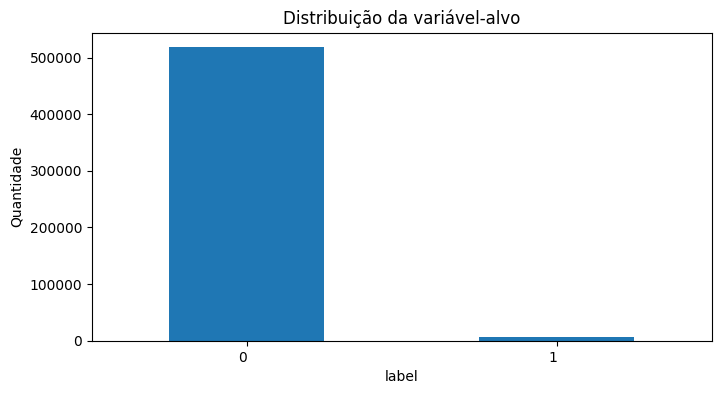

In [ ]:
if target != '':
    plt.figure(figsize=(8, 4))
    if df[target].nunique() <= 20:
        df[target].value_counts(dropna=False).plot(kind='bar')
        plt.title('Distribuição da variável-alvo')
        plt.xlabel(target)
        plt.ylabel('Quantidade')
        plt.xticks(rotation=0, ha='right')
    else:
        df[target].plot(kind='hist', bins=30)
        plt.title('Distribuição da variável-alvo')
        plt.xlabel(target)
    plt.show()
else:
    print('Defina a variável target antes de executar esta célula.')

### Interpretação da variável-alvo

Responda:

- A) A variável-alvo está balanceada?
- B) Existem classes muito mais frequentes que outras?
- C) Se for regressão, os valores parecem concentrados ou espalhados?
- D) Isso pode afetar o desempenho do modelo?

**Resposta do grupo:**

- A) Não. Podemos perceber que há uma quantidade de instâncias com o label = "0" muito maior do que instâncias com o label = "1".
- B) No nosso caso de classificador binário, sim, há uma classe mais frequente que a outra.
- C) Não é regressão.
- D) Sim, o modelo pode ter um viés muito grande para classificar itens como da classe "0", pois existem muito mais instâncias desse tipo na base.

## 8. Análise das variáveis categóricas

Vamos observar quais categorias aparecem em cada coluna categórica.

In [36]:
# Separar colunas categóricas
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

In [35]:
# Observe que a saída será vazia pois na base não há colunas categóricas. Todas são numéricas.

for col in cat_cols:
    print('\n' + '='*80)
    print(f'Coluna: {col}')
    print('Quantidade de categorias únicas:', df[col].nunique(dropna=False))
    display(df[col].value_counts(dropna=False).head(10))

In [34]:
# Observe que a saída será vazia pois na base não há colunas categóricas. Todas são numéricas.

# Gráficos das principais variáveis categóricas
for col in cat_cols[:5]:
    plt.figure(figsize=(10, 4))
    df[col].value_counts(dropna=False).head(10).plot(kind='bar')
    plt.title(f'Top 10 categorias - {col}')
    plt.xlabel(col)
    plt.ylabel('Quantidade')
    plt.xticks(rotation=45, ha='right')
    plt.show()

### Interpretação das variáveis categóricas

Responda:

- Quais colunas categóricas parecem importantes?
- Alguma coluna tem categorias demais?
- Será necessário aplicar codificação, como One-Hot Encoding ou Label Encoding?

**Resposta do grupo:**

- Na nossa base não há ocorrências de valores categóricos, por isso, não será necessário aplicar uma codificação.

## 9. Análise das variáveis numéricas

Vamos visualizar a distribuição das principais variáveis numéricas.

In [37]:
# Separar colunas numéricas
num_cols = df.select_dtypes(include=np.number).columns.tolist()

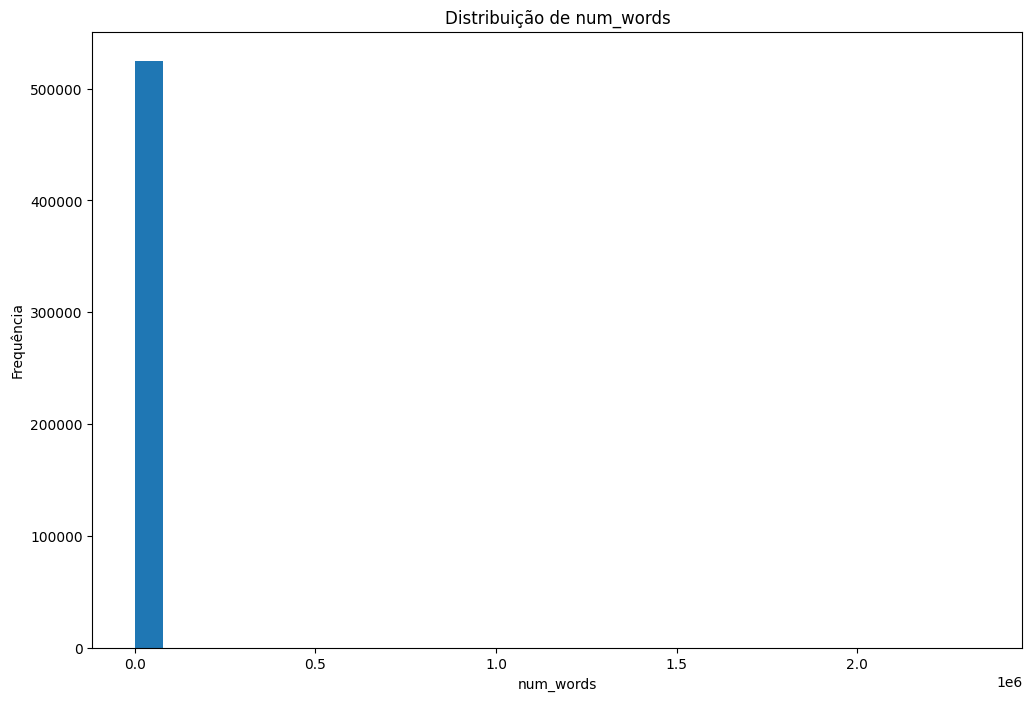

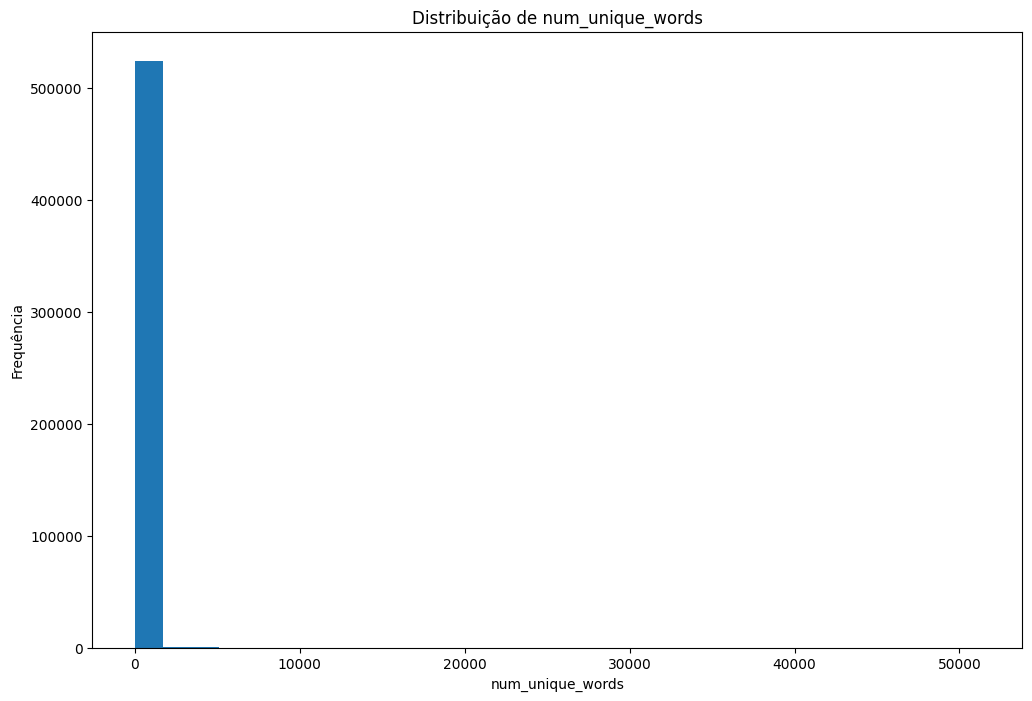

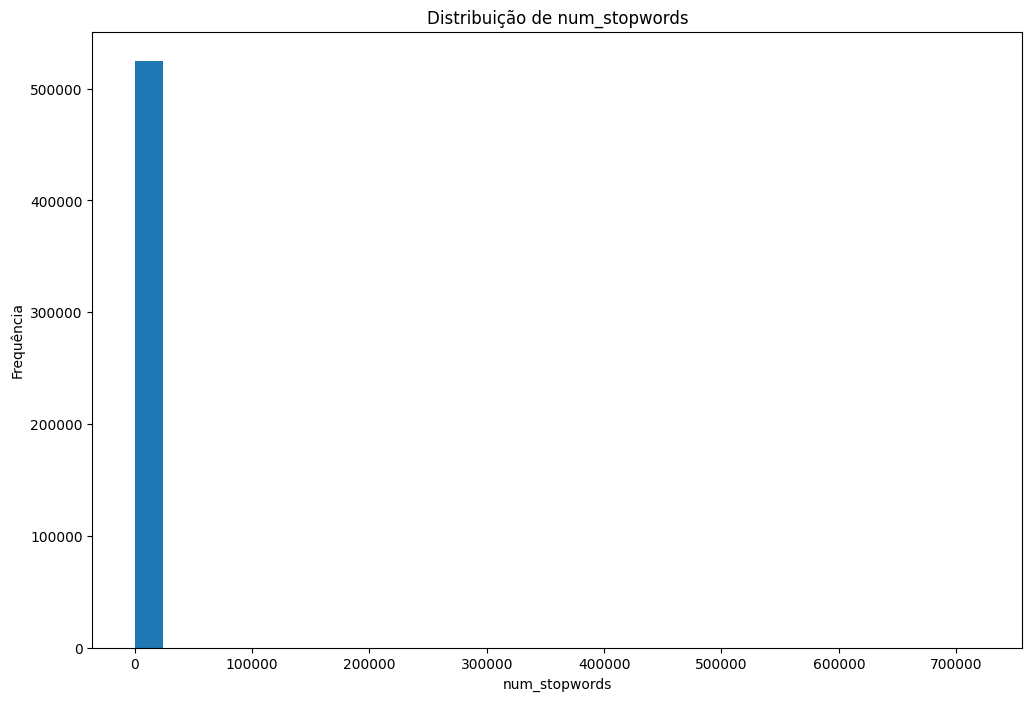

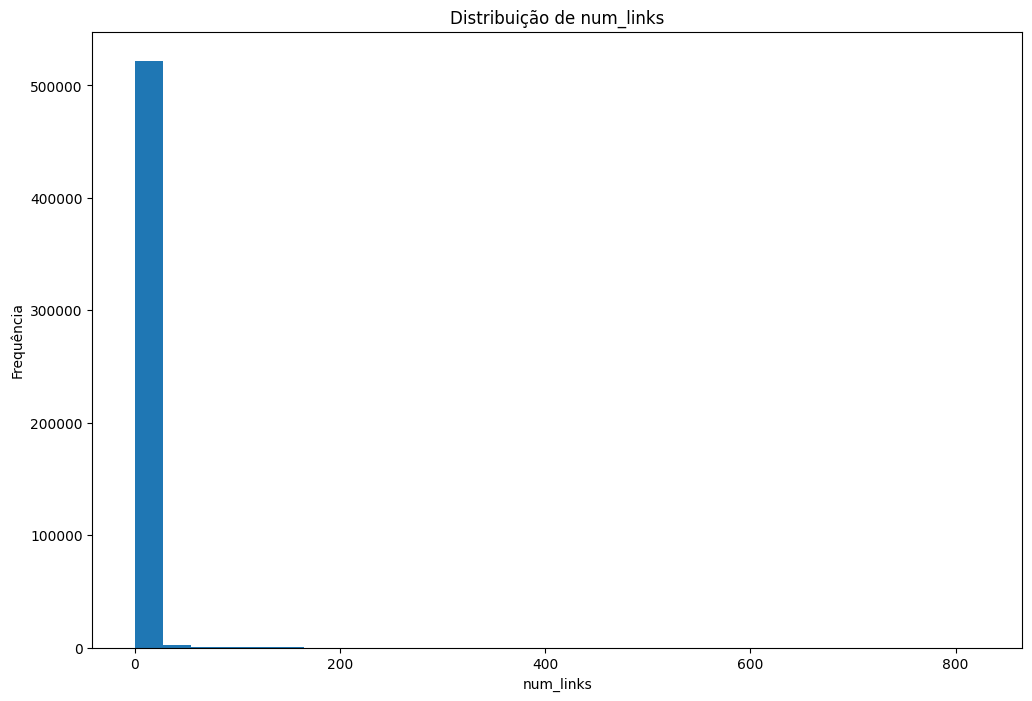

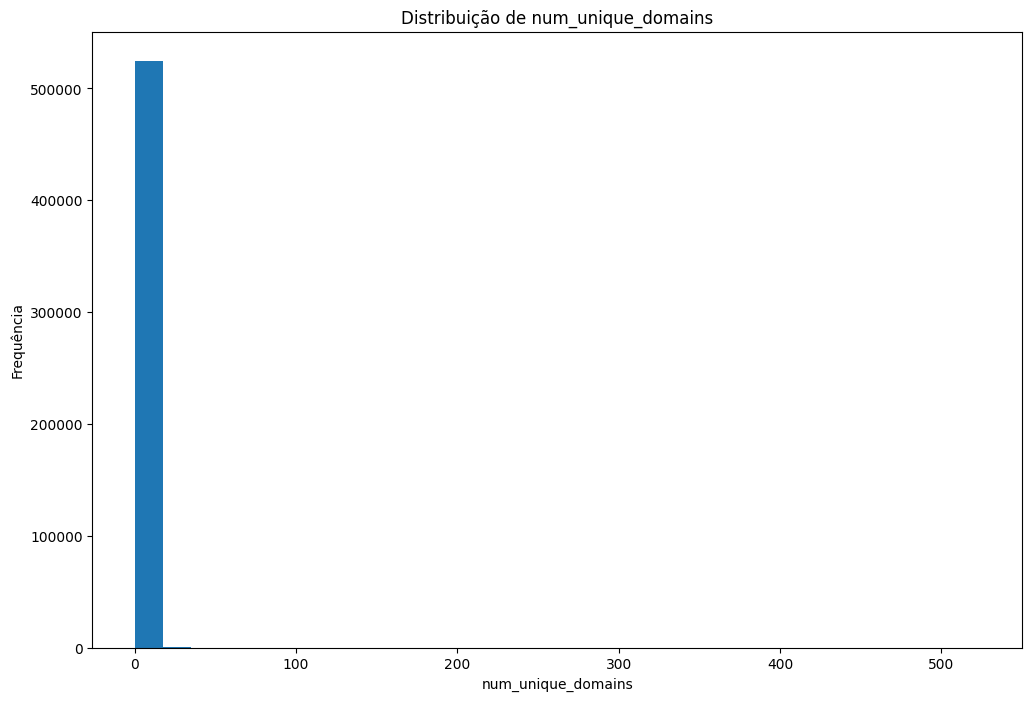

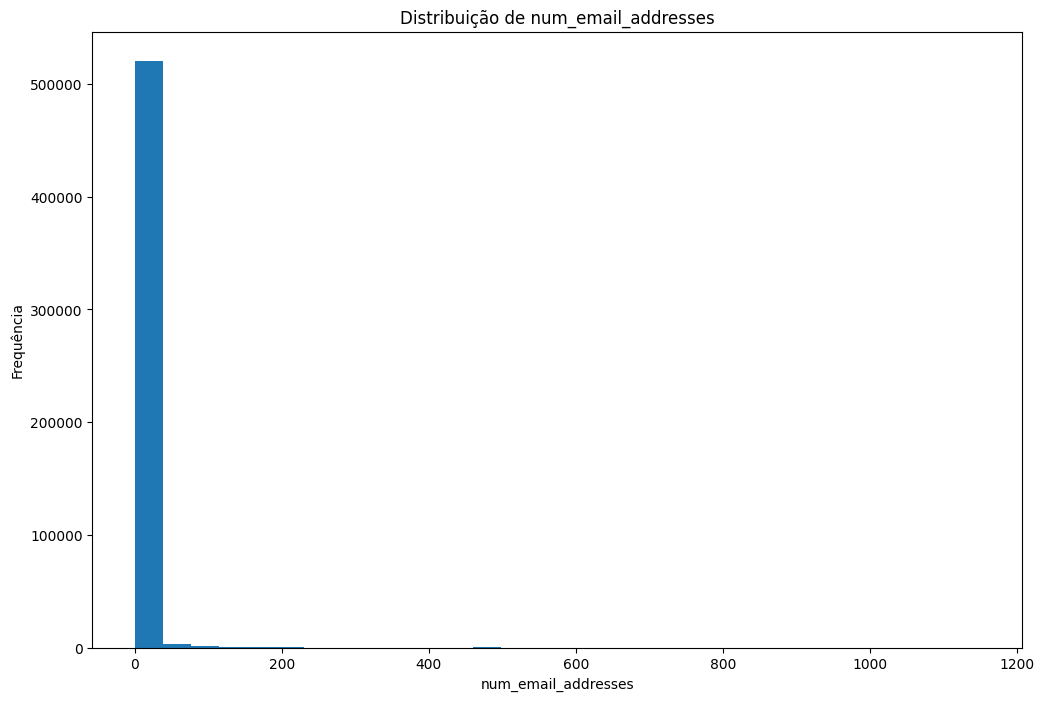

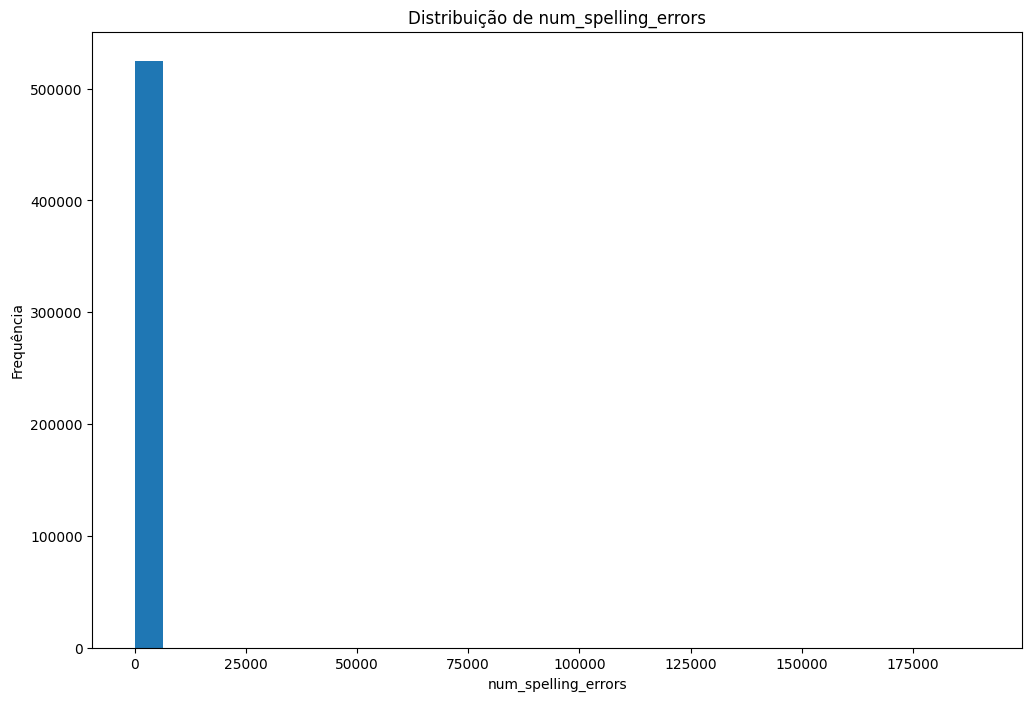

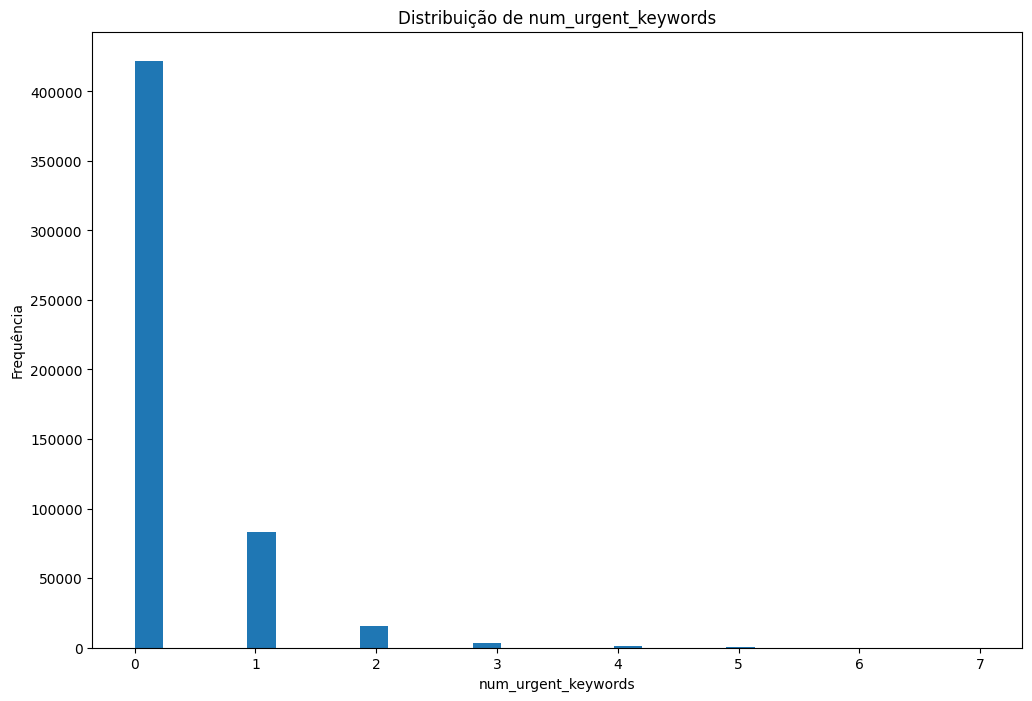

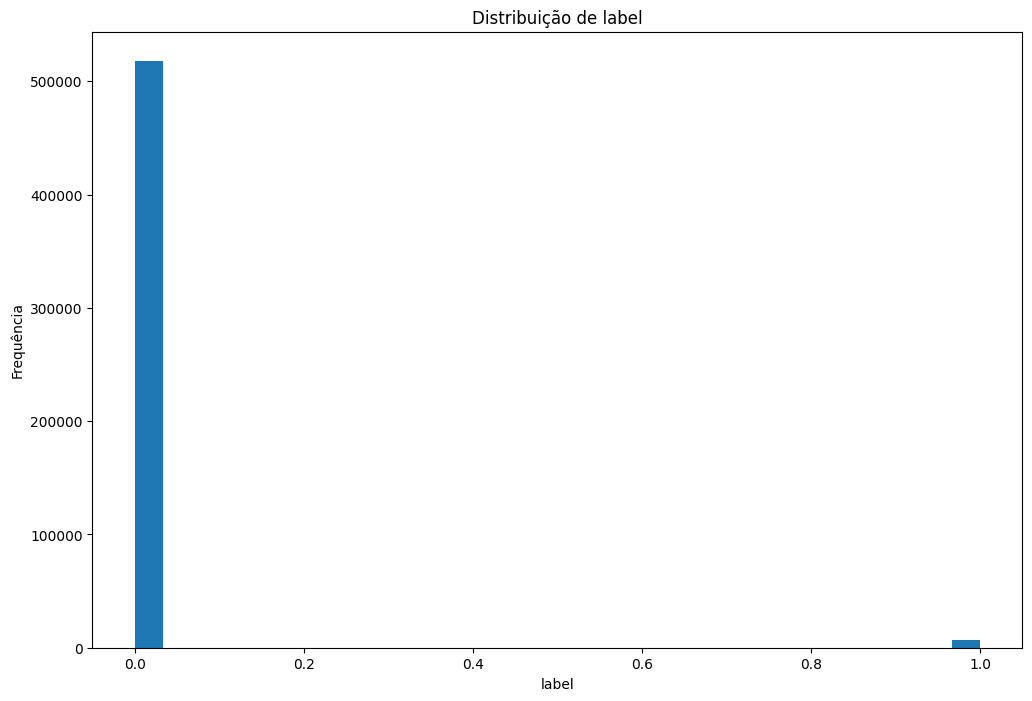

In [48]:
# Histogramas das variáveis numéricas
for col in num_cols[:10]:
    plt.figure(figsize=(12, 8))
    df[col].plot(kind='hist', bins=30)
    plt.title(f'Distribuição de {col}')
    plt.xlabel(col)
    plt.ylabel('Frequência')
    plt.show()

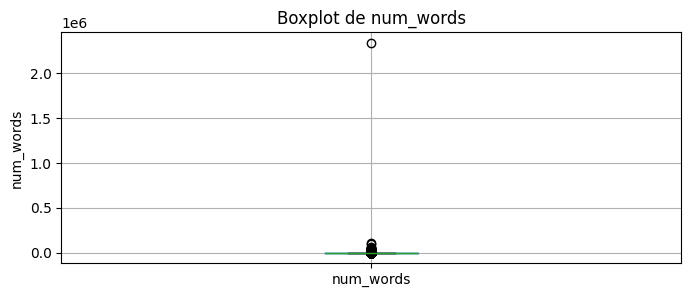

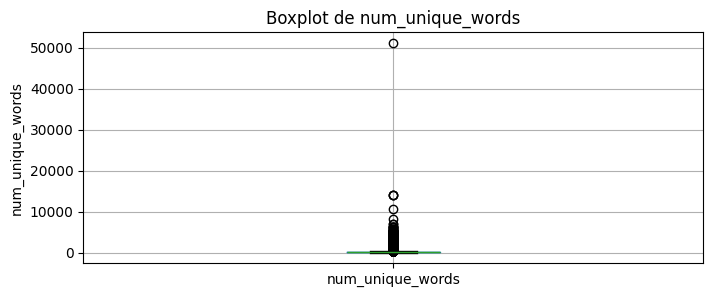

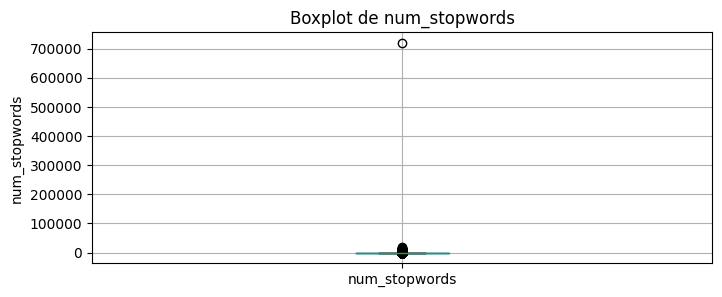

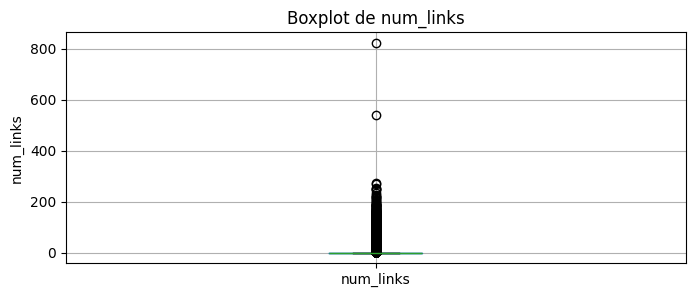

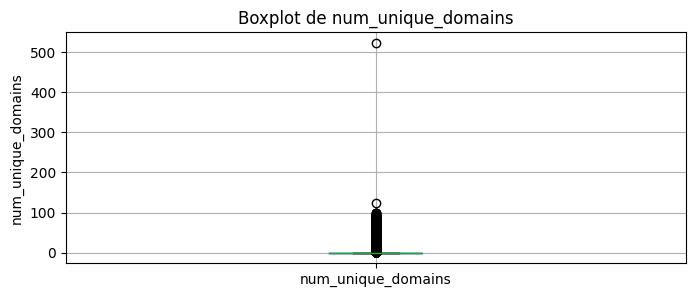

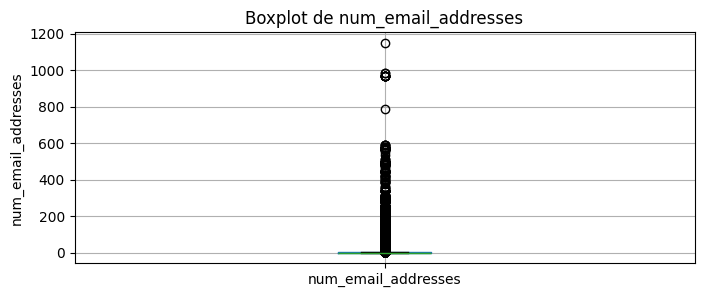

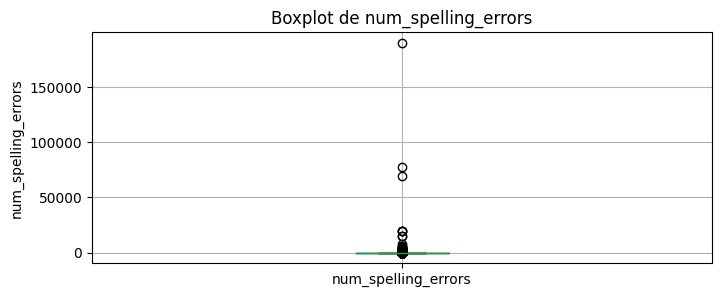

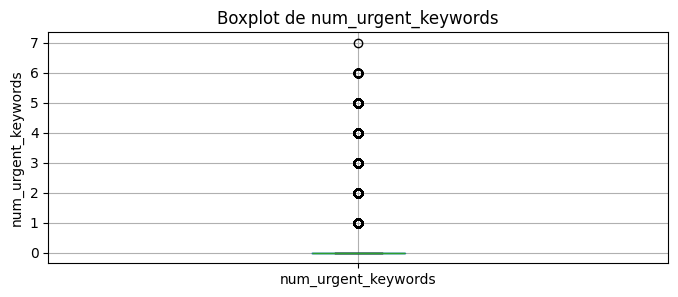

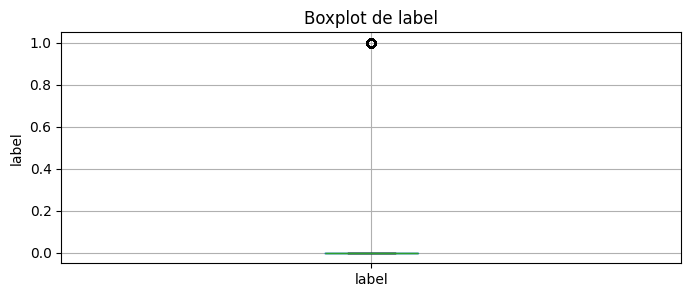

In [49]:
# Boxplots para observar possíveis outliers
for col in num_cols[:10]:
    plt.figure(figsize=(8, 3))
    df.boxplot(column=col)
    plt.title(f'Boxplot de {col}')
    plt.ylabel(col)
    plt.show()

### Interpretação das variáveis numéricas

Responda:

- A) Quais variáveis têm distribuição mais concentrada?
- B) Quais apresentam possíveis outliers?
- C) Alguma variável pode precisar de padronização ou normalização?

**Resposta do grupo:**

- A) Todas as variáveis do dataset possuem distribuição bastante concentrada (perto de zero). Isso pode ser notado nos histogramas, onde quase 100% da frequência está na primeira barra.
- B) Todas essas variáveis apresentam muitos outliers. Podemos notar, por exemplo, que no boxplot da variável "num_words" existe uma instância que distoa muito das demais (apresentando 2 milhões de palavras).
- C) Sim, todas elas (exceto "label") precisarão de normalização para não predujicarem o treinamento do modelo

## 10. Relação entre variáveis e a variável-alvo

Agora vamos investigar quais variáveis podem estar relacionadas com a saída.

In [50]:
# Correlação entre variáveis numéricas
if len(num_cols) > 1:
    corr = df[num_cols].corr(numeric_only=True)
    corr
else:
    print('Não há colunas numéricas suficientes para calcular correlação.')

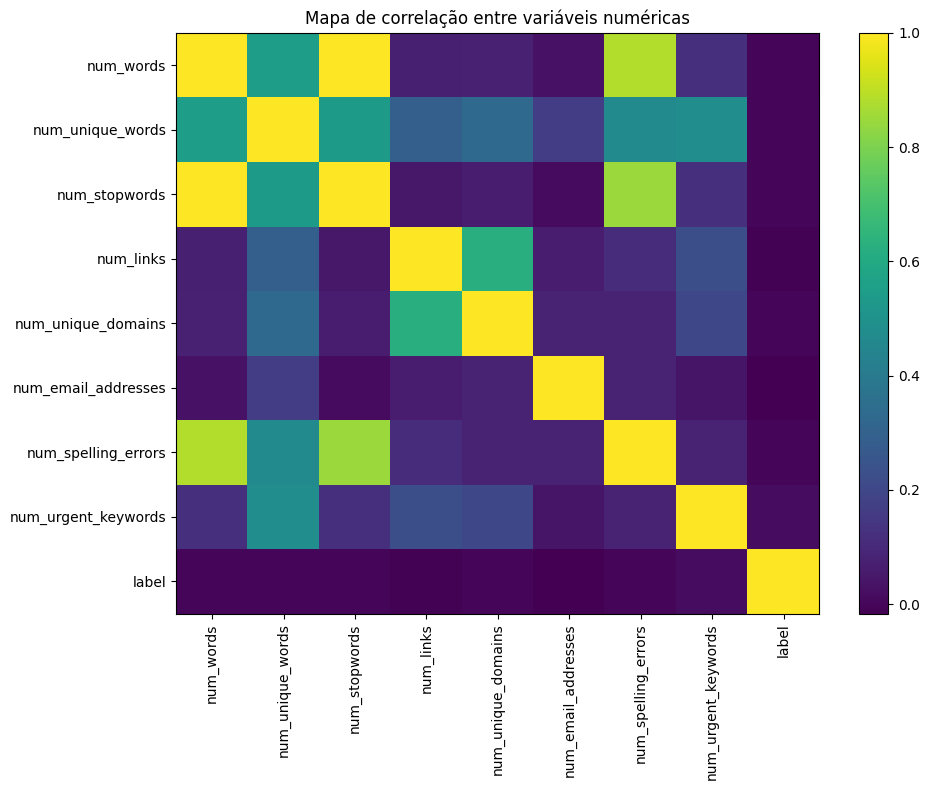

In [51]:
# Mapa de correlação usando matplotlib
if len(num_cols) > 1:
    plt.figure(figsize=(10, 8))
    plt.imshow(corr, aspect='auto')
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.title('Mapa de correlação entre variáveis numéricas')
    plt.tight_layout()
    plt.show()
else:
    print('Não há colunas numéricas suficientes para calcular correlação.')

In [52]:
# Correlação das variáveis numéricas com o target, caso o target também seja numérico
if target != '' and target in num_cols:
    target_corr = df[num_cols].corr(numeric_only=True)[target].sort_values(ascending=False)
    display(target_corr)
else:
    print('O target não é numérico ou ainda não foi definido. Para classificação, analise por grupos nas próximas células.')

,label
label,1.000000
num_urgent_keywords,0.018400
num_unique_words,0.003038
num_stopwords,-0.000491
num_words,-0.001045
num_spelling_errors,-0.002059
num_unique_domains,-0.002524
num_links,-0.009757
num_email_addresses,-0.016519


In [53]:
# Comparação de médias das variáveis numéricas por classe do target
# Útil para problemas de classificação
if target != '' and df[target].nunique() <= 20:
    display(df.groupby(target)[num_cols].mean(numeric_only=True).T)
else:
    print('Esta análise é mais adequada quando o target é categórico com poucas classes.')

label,0,1
num_words,276.631566,246.150957
num_unique_words,122.941205,128.300907
num_stopwords,80.103611,75.711901
num_links,0.901921,0.423658
num_unique_domains,0.348285,0.309109
num_email_addresses,2.140906,0.176428
num_spelling_errors,24.768971,19.161750
num_urgent_keywords,0.244108,0.334149
label,0.000000,1.000000


### Interpretação das relações com a variável-alvo

Responda:

- A) Quais variáveis parecem mais relacionadas com a saída?
- B) Existe alguma correlação forte?
- C) Existem variáveis redundantes entre si?
- D) Que hipóteses o grupo consegue levantar?

**Resposta do grupo:**

- A) Não existem variáveis relacionadas com a saída. Todas elas possuem um índice de correlação muito próxima a zero.
- B) Sim, mas não com a variável alvo ("label"). Entre as outras variáveis, existem correlações muito fortes, como podemos ver no heatmap (ex.: Correlação muito forte entre "num_words", "num_stopwords" = Área amarela no mapa)
- C) Sim. Variáveis que contabilizam o número total de palavras (num_words) e um número de um tipo específico de palavras (como num_stopwords) acabam sendo redundantes.
- D) Percebemos que a presença de muitos outliers acaba gerando numa correlação baixíssima de variáveis com a variável alvo. Além disso, conseguimos observar que a variável "num_urgent_words" tem uma correlação com o "label" ligeiramente maior que as outras variáveis, confirmando a ideia que tivemos na entrega 01.

## 11. Possíveis problemas da base

Analise criticamente a base antes de treinar modelos.

In [54]:
# Verificar duplicatas
duplicadas = df.duplicated().sum()
print(f'Quantidade de linhas duplicadas: {duplicadas}')

Quantidade de linhas duplicadas: 319794


In [55]:
# Cardinalidade: quantidade de valores únicos por coluna
cardinalidade = df.nunique(dropna=False).sort_values(ascending=False)
cardinalidade

,0
num_words,4278
num_unique_words,1892
num_stopwords,1885
num_spelling_errors,1066
num_email_addresses,285
num_links,197
num_unique_domains,82
num_urgent_keywords,8
label,2


### Checklist de problemas

Marque o que apareceu na base:

- [ ] Valores ausentes
- [X] Linhas duplicadas
- [X] Outliers
- [X] Classes desbalanceadas
- [ ] Colunas irrelevantes ou identificadores
- [ ] Variáveis categóricas que precisam de codificação
- [X] Variáveis numéricas que precisam de normalização
- [ ] Possível vazamento de dados

Explique:

- Observamos que nosso dataset possui muitas (319794) linhas duplicadas, muitos outliers (como observado nos boxplots) e algumas classes desbalanceadas, como ocorre na variável alvo "label". Além disso, notamos também que quase todas as variáveis do dataset precisarão de normalização, pois estão em escalas muito diferentes.

## 12. Planejamento da modelagem

Com base na exploração feita, o grupo deve planejar os próximos passos.

### Perguntas para responder

1. Qual é a variável-alvo?
2. O problema é classificação ou regressão?
3. Quais colunas serão usadas como entrada?
4. Quais colunas podem ser removidas?
5. Quais tratamentos serão necessários?
6. Quais algoritmos o grupo pretende testar?

Sugestões de algoritmos:

**Classificação:**

- KNN
- Regressão Logística
- Árvore de Decisão
- Random Forest
- Naive Bayes
- SVM

**Regressão:**

- Regressão Linear
- KNN Regressor
- Árvore de Regressão
- Random Forest Regressor
- SVR

### Resposta do grupo

1. A variável "label".
2. O problema é de classificação, mais especificamente classificação binária.
3. Inicialmente utilizaremos todas as colunas.
4. Iremos fazer uma análise de correlação mais profunda, mas se os valores realmente confirmarem que certas variáveis (como num_stopwords e num_unique_domains) são redundante com outras (como num_words num_links), então elas serão removidas.
5. Precisaremos remover as linhas duplicadas, tratar os outliers e normalizar os valores numéricos para lidar com a assimetria das distribuições.
6. Testaremos algoritmos baseados em árvores, como Árvores de Decisão, pois eles são bons classificadores e mais imunes a outliers.


## 13. Mini-relatório final da exploração

Escreva um resumo final, em formato de texto, explicando o que o grupo entendeu da base.

O texto deve responder:

- Qual é o objetivo do projeto?
- O que cada linha da base representa?
- Qual é a variável-alvo?
- Quais variáveis parecem mais importantes?
- Quais problemas foram encontrados?
- Quais decisões serão tomadas antes do treinamento?
- Quais modelos serão testados inicialmente?

### Mini-relatório

O objetivo do projeto é detectar a presença de phishing em emails, classificando-os em duas categorias distintas: 0, para emails que não possuem phishing e 1, para emails que possuem phishing. Cada linha da base de dados corresponde a um email diferente, e as colunas representam características da estrutura do texto desse email.

A variável-alvo que queremos prever é a "label", que indica justamente se um email possui phishing ou não. Fazendo a análise individual de cada variável com o alvo, identificamos que "num_email_addresses", "num_links" e "num_urgent_keywords" parecem ser as mais importantes para separar as classes, já que suas médias variam consideravelmente entre a classe 0 e a classe 1.

No entanto, encontramos diversos desafios na base. O principal deles é a presença massiva de dados duplicados (quase 320 mil linhas) e distribuições extremamente assimétricas. Quase todas as variáveis numéricas possuem concentração no valor zero, mas com outliers extremos que alteram a escala para valores astronômicos. Além disso, também identificamos redundância entre algumas variáveis, como num_words e num_stopwords.

Tendo em vista todos os pontos citados acima, vamos, antes de treinar o modelo, aplicar algumas técnicas de normalização e remoção de outliers,  remover colunas redundantes, além da exclusão de valores duplicados. Feito isso, iniciaremos nossos testes utilizando  algoritmos robustos a dados assimétricos, como Random Forest e Árvores de Decisão. Além disso, também utilizaremos outros modelos como Regressão Logística para que tenhamos um parâmetro de comparação.